<a href="https://colab.research.google.com/github/raaghavkk/UG04-NLP-COMM061/blob/main/notebooks/raaghav_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UG04 — Data Analysis & Visualisation
**COMM061 NLP Coursework | Raaghav Kulshreshtha | 6776090**

In [2]:
# Install required libraries
!pip install datasets

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

## 1. Load Dataset

In [4]:
ds = load_dataset("surrey-nlp/BESSTIE-CW-26")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})


In [5]:
df_train = pd.DataFrame(ds['train'])
df_val = pd.DataFrame(ds['validation'])
df_test = pd.DataFrame(ds['test'])

print(df_train.head())
print(df_train.columns.tolist())

                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   
3  Firstly the staff seemed as if they did n't wa...   en-UK  Google   
4  We came for lunch and enjoyed the food we orde...   en-UK  Google   

   Sentiment  Sarcasm  
0        0.0      0.0  
1        0.0      1.0  
2        1.0      0.0  
3        0.0      0.0  
4        1.0      0.0  
['text', 'variety', 'source', 'Sentiment', 'Sarcasm']


## 2. Dataset Statistics

In [6]:
print("Training set shape:", df_train.shape)
print("Validation set shape:", df_val.shape)
print("Test set shape:", df_test.shape)

print("\nVariety counts (train):")
print(df_train['variety'].value_counts())

print("\nSource counts (train):")
print(df_train['source'].value_counts())

Training set shape: (3747, 5)
Validation set shape: (313, 5)
Test set shape: (2183, 5)

Variety counts (train):
variety
en-IN    1399
en-UK    1203
en-AU    1145
Name: count, dtype: int64

Source counts (train):
source
Google    1874
Reddit    1873
Name: count, dtype: int64


## 3. Label Distribution Visualisation (Q1.1)

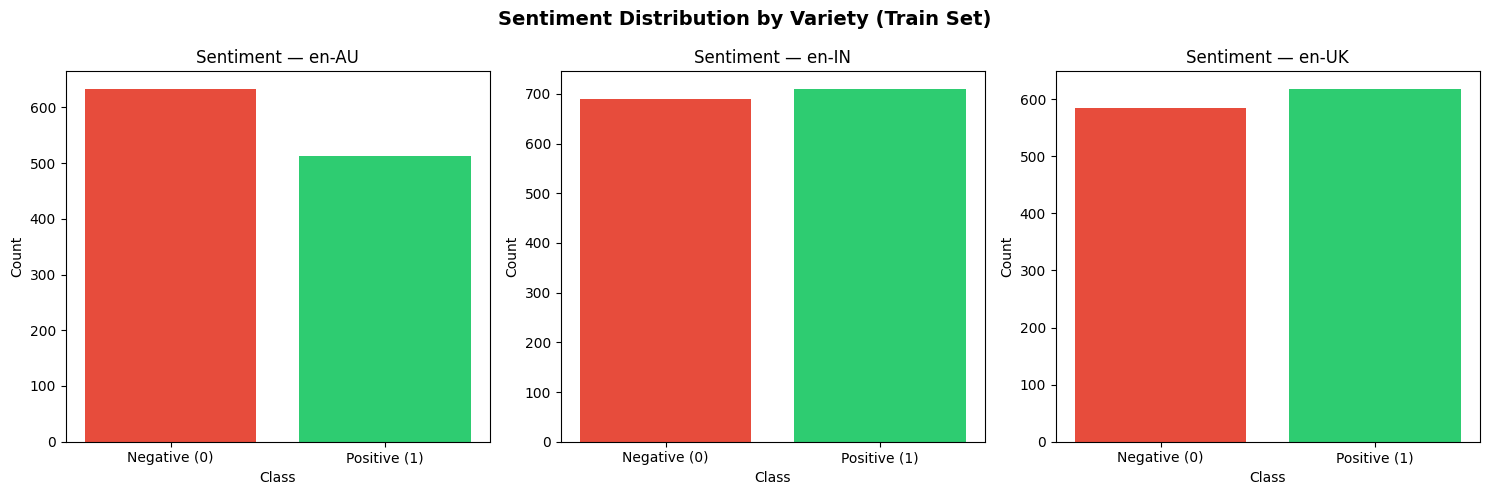

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

varieties = ['en-AU', 'en-IN', 'en-UK']
for i, variety in enumerate(varieties):
    subset = df_train[df_train['variety'] == variety]
    counts = subset['Sentiment'].value_counts().sort_index()
    axes[i].bar(['Negative (0)', 'Positive (1)'], counts.values, color=['#e74c3c', '#2ecc71'])
    axes[i].set_title(f'Sentiment — {variety}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('Class')

plt.suptitle('Sentiment Distribution by Variety (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

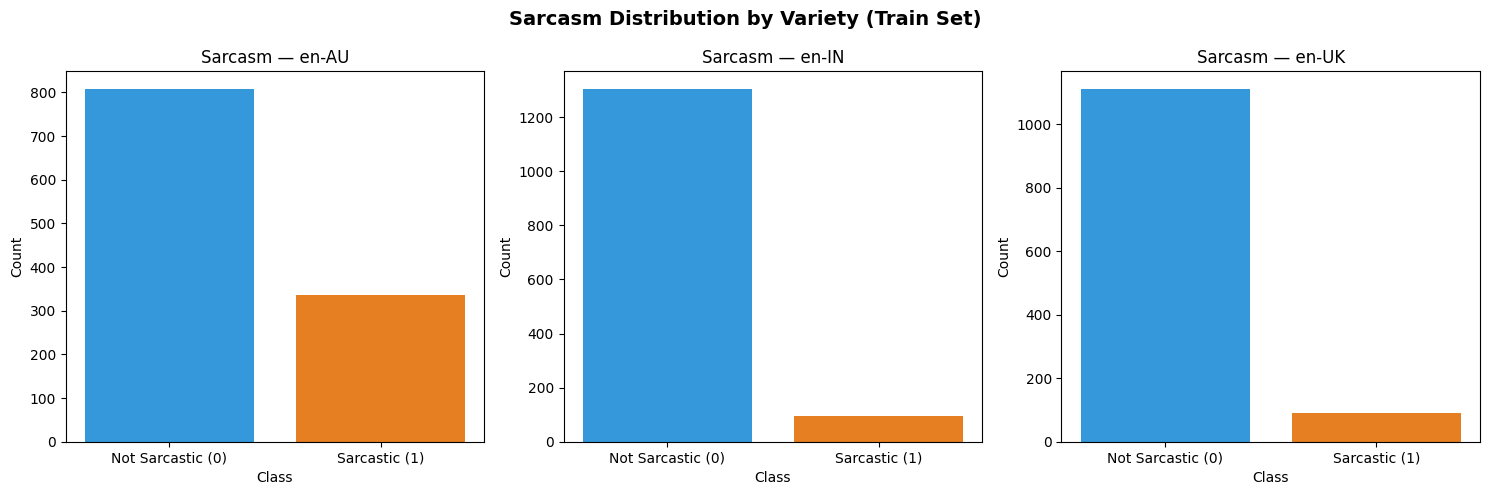

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, variety in enumerate(varieties):
    subset = df_train[df_train['variety'] == variety]
    counts = subset['Sarcasm'].value_counts().sort_index()
    axes[i].bar(['Not Sarcastic (0)', 'Sarcastic (1)'], counts.values, color=['#3498db', '#e67e22'])
    axes[i].set_title(f'Sarcasm — {variety}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('Class')

plt.suptitle('Sarcasm Distribution by Variety (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sarcasm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()